Shape: (10, 6)


,Hours_Studied,Previous_Scores,Attendance,Gender,Passed,Final_Score
0,5,67,90,Male,Yes,78
1,3,45,75,Female,No,50
2,8,88,95,Male,Yes,92
3,2,35,60,Female,No,40
4,6,75,85,Male,Yes,85


Hours_Studied       int64
Previous_Scores     int64
Attendance          int64
Gender             object
Passed             object
Final_Score         int64
dtype: object
Hours_Studied      0
Previous_Scores    0
Attendance         0
Gender             0
Passed             0
Final_Score        0
dtype: int64


,Hours_Studied,Previous_Scores,Attendance,Final_Score
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,66.800000,80.900000,72.400000
std,3.02765,24.827404,16.602878,24.079498
min,1.00000,30.000000,50.000000,35.000000
25%,3.25000,47.000000,71.250000,52.500000
50%,5.50000,71.000000,86.500000,81.500000
75%,7.75000,86.500000,93.750000,91.250000
max,10.00000,98.000000,99.000000,99.000000


,Hours_Studied,Previous_Scores,Attendance,Gender,Passed,Final_Score,Gender_enc,Passed_enc
0,5,67,90,Male,Yes,78,1,1
1,3,45,75,Female,No,50,0,0
2,8,88,95,Male,Yes,92,1,1
3,2,35,60,Female,No,40,0,0
4,6,75,85,Male,Yes,85,1,1
5,7,82,88,Female,Yes,89,0,1
6,4,53,70,Female,No,60,0,0
7,1,30,50,Male,No,35,1,0
8,9,95,97,Male,Yes,96,1,1
9,10,98,99,Female,Yes,99,0,1


R² Score : 0.9606
MAE      : 3.6346
RMSE     : 4.0164
  Hours_Studied: -11.6719
  Previous_Scores: 2.3834
  Attendance: 0.0363
  Gender_enc: -5.0072
  Intercept: -21.9559


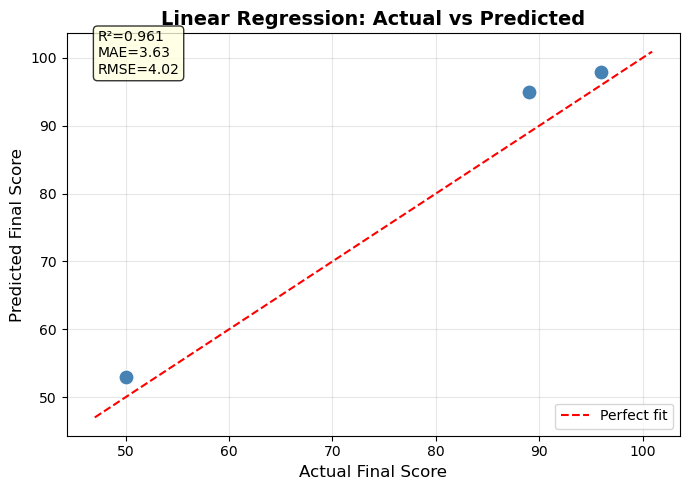

KNN k=5 Unscaled:
  Accuracy : 1.0000
  F1-Score : 1.0000
  Confusion Matrix:
[[1 0]
 [0 2]]

KNN k=5 Scaled:
  Accuracy : 1.0000
  F1-Score : 1.0000
  Confusion Matrix:
[[1 0]
 [0 2]]
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

k=3: unscaled=1.000, scaled=1.000
k=5: unscaled=1.000, scaled=1.000
k=7: unscaled=0.667, scaled=0.667


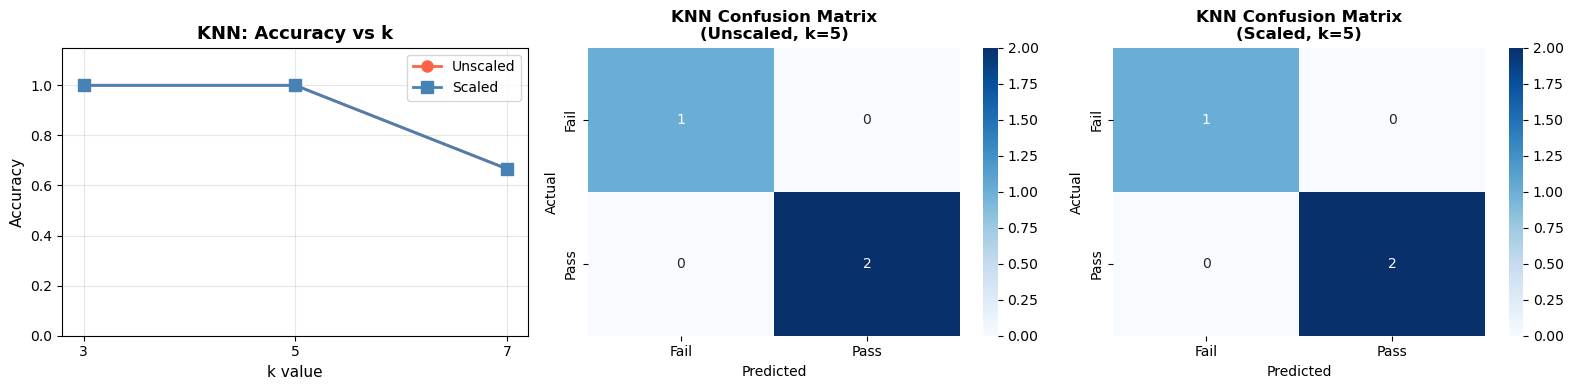

Accuracy : 1.0000
F1-Score : 1.0000
Confusion Matrix:
[[1 0]
 [0 2]]
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



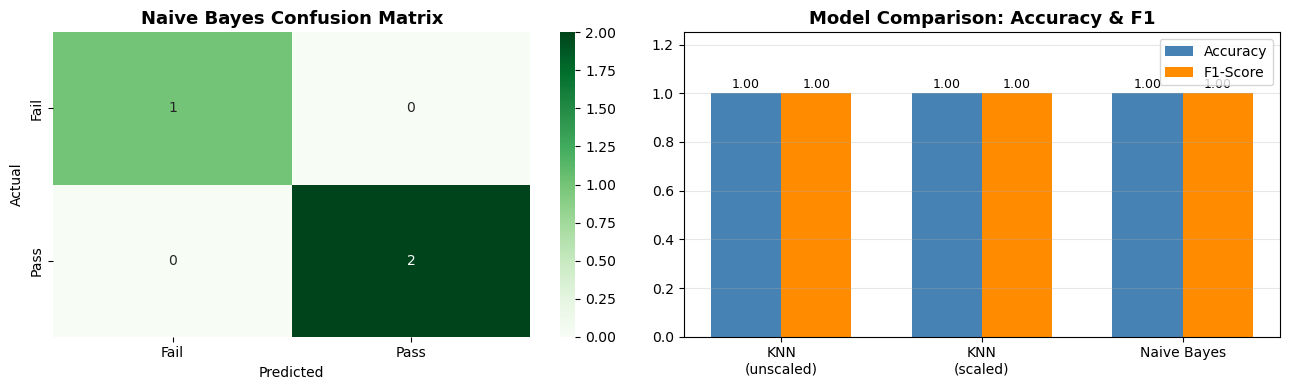

FINAL SUMMARY
Linear Regression  →  R²=0.961, MAE=3.63, RMSE=4.02
KNN k=5 (unscaled) →  Acc=1.000, F1=1.000
KNN k=5 (scaled)   →  Acc=1.000, F1=1.000
Naive Bayes (GNB)  →  Acc=1.000, F1=1.000
k=3 → unscaled=1.000, scaled=1.000
k=5 → unscaled=1.000, scaled=1.000
k=7 → unscaled=0.667, scaled=0.667


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, confusion_matrix, f1_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('student_scores_data-ml1-ass2-data (1).csv')
print("Shape:", df.shape)
display(df.head())
print(df.dtypes)
print(df.isnull().sum())
display(df.describe())

le = LabelEncoder()
df['Gender_enc'] = le.fit_transform(df['Gender'])
df['Passed_enc'] = (df['Passed'] == 'Yes').astype(int)
display(df)

features_reg = ['Hours_Studied', 'Previous_Scores', 'Attendance', 'Gender_enc']
X_reg = df[features_reg]
y_reg = df['Final_Score']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_r = lr.predict(X_test_r)
r2   = r2_score(y_test_r, y_pred_r)
mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")
for feat, coef in zip(features_reg, lr.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  Intercept: {lr.intercept_:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_r, y_pred_r, color='steelblue', edgecolors='white', s=120, zorder=3)
mn = min(y_test_r.min(), y_pred_r.min()) - 3
mx = max(y_test_r.max(), y_pred_r.max()) + 3
ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual Final Score', fontsize=12)
ax.set_ylabel('Predicted Final Score', fontsize=12)
ax.set_title('Linear Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
ax.legend()
ax.text(0.05, 0.90, f'R²={r2:.3f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_regression.png', dpi=150)
plt.show()

features_cls = ['Hours_Studied', 'Previous_Scores', 'Attendance', 'Gender_enc']
X_cls = df[features_cls]
y_cls = df['Passed_enc']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.3, random_state=42)

knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_c, y_train_c)
y_pred_knn = knn5.predict(X_test_c)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_c)
X_test_s  = scaler.transform(X_test_c)
knn5s = KNeighborsClassifier(n_neighbors=5)
knn5s.fit(X_train_s, y_train_c)
y_pred_knns = knn5s.predict(X_test_s)

print("KNN k=5 Unscaled:")
print(f"  Accuracy : {accuracy_score(y_test_c, y_pred_knn):.4f}")
print(f"  F1-Score : {f1_score(y_test_c, y_pred_knn, zero_division=0):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_test_c, y_pred_knn)}")
print("\nKNN k=5 Scaled:")
print(f"  Accuracy : {accuracy_score(y_test_c, y_pred_knns):.4f}")
print(f"  F1-Score : {f1_score(y_test_c, y_pred_knns, zero_division=0):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_test_c, y_pred_knns)}")
print(classification_report(y_test_c, y_pred_knns, target_names=['Fail', 'Pass'], zero_division=0))

k_values = [3, 5, 7]
accs_unscaled, accs_scaled = [], []
for k in k_values:
    m1 = KNeighborsClassifier(n_neighbors=k)
    m1.fit(X_train_c, y_train_c)
    accs_unscaled.append(accuracy_score(y_test_c, m1.predict(X_test_c)))
    m2 = KNeighborsClassifier(n_neighbors=k)
    m2.fit(X_train_s, y_train_c)
    accs_scaled.append(accuracy_score(y_test_c, m2.predict(X_test_s)))
for k, u, s in zip(k_values, accs_unscaled, accs_scaled):
    print(f"k={k}: unscaled={u:.3f}, scaled={s:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(k_values, accs_unscaled, 'o-', color='tomato',    label='Unscaled', lw=2, ms=8)
axes[0].plot(k_values, accs_scaled,   's-', color='steelblue', label='Scaled',   lw=2, ms=8)
axes[0].set_xlabel('k value', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('KNN: Accuracy vs k', fontsize=13, fontweight='bold')
axes[0].set_xticks(k_values)
axes[0].set_ylim(0, 1.15)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
cm_knn = confusion_matrix(y_test_c, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'])
axes[1].set_title('KNN Confusion Matrix\n(Unscaled, k=5)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
cm_knns = confusion_matrix(y_test_c, y_pred_knns)
sns.heatmap(cm_knns, annot=True, fmt='d', cmap='Blues', ax=axes[2], xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'])
axes[2].set_title('KNN Confusion Matrix\n(Scaled, k=5)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('plot_knn.png', dpi=150)
plt.show()

gnb = GaussianNB()
gnb.fit(X_train_c, y_train_c)
y_pred_nb = gnb.predict(X_test_c)
acc_nb = accuracy_score(y_test_c, y_pred_nb)
f1_nb  = f1_score(y_test_c, y_pred_nb, zero_division=0)
cm_nb  = confusion_matrix(y_test_c, y_pred_nb)
print(f"Accuracy : {acc_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}")
print(f"Confusion Matrix:\n{cm_nb}")
print(classification_report(y_test_c, y_pred_nb, target_names=['Fail', 'Pass'], zero_division=0))

acc_knn  = accuracy_score(y_test_c, y_pred_knn)
f1_knn   = f1_score(y_test_c, y_pred_knn, zero_division=0)
acc_knns = accuracy_score(y_test_c, y_pred_knns)
f1_knns  = f1_score(y_test_c, y_pred_knns, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', ax=axes[0], xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'])
axes[0].set_title('Naive Bayes Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
models   = ['KNN\n(unscaled)', 'KNN\n(scaled)', 'Naive Bayes']
accs_all = [acc_knn, acc_knns, acc_nb]
f1s_all  = [f1_knn,  f1_knns,  f1_nb]
x = np.arange(len(models)); w = 0.35
bars1 = axes[1].bar(x - w/2, accs_all, w, label='Accuracy', color='steelblue')
bars2 = axes[1].bar(x + w/2, f1s_all,  w, label='F1-Score',  color='darkorange')
for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(models, fontsize=10)
axes[1].set_ylim(0, 1.25)
axes[1].set_title('Model Comparison: Accuracy & F1', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plot_nb_comparison.png', dpi=150)
plt.show()

print("=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"Linear Regression  →  R²={r2:.3f}, MAE={mae:.2f}, RMSE={rmse:.2f}")
print(f"KNN k=5 (unscaled) →  Acc={acc_knn:.3f}, F1={f1_knn:.3f}")
print(f"KNN k=5 (scaled)   →  Acc={acc_knns:.3f}, F1={f1_knns:.3f}")
print(f"Naive Bayes (GNB)  →  Acc={acc_nb:.3f}, F1={f1_nb:.3f}")
print(f"k=3 → unscaled={accs_unscaled[0]:.3f}, scaled={accs_scaled[0]:.3f}")
print(f"k=5 → unscaled={accs_unscaled[1]:.3f}, scaled={accs_scaled[1]:.3f}")
print(f"k=7 → unscaled={accs_unscaled[2]:.3f}, scaled={accs_scaled[2]:.3f}")